<a href="https://colab.research.google.com/github/young0206/computer_vision/blob/main/06.%EC%9E%84%EB%B2%A0%EB%94%94%EB%93%9C/03.EfficientNet/notebook_tf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mounting Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
cd drive/MyDrive/33project/06.임베디드/03.efficientNet-2/tensorflow/efficientnet_tf

/content/drive/MyDrive/33project/06.임베디드/03.efficientNet-2/tensorflow/efficientnet_tf


# Installing Dependencies

In [4]:
!pip3 install tensorflow==1.13.1 # newer version may not work

ERROR: Could not find a version that satisfies the requirement tensorflow==1.13.1 (from versions: 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0, 2.22.0rc0)
ERROR: No matching distribution found for tensorflow==1.13.1


KeyboardInterrupt: 

In [5]:
import sys
import tensorflow as tf

print("Python:", sys.version)
print("TensorFlow:", tf.__version__)

Python: 3.13.15 (main, Aug  6 2026, 11:06:22) [GCC 13.3.0]
TensorFlow: 2.21.0


# Importing Modules

In [6]:
import os

print("현재 위치:", os.getcwd())
print("\n현재 폴더 파일:")
print(os.listdir())

현재 위치: /content/drive/MyDrive/33project/06.임베디드/03.efficientNet-2/tensorflow/efficientnet_tf

현재 폴더 파일:
['imagenet_input.py', 'preprocessing.py', 'efficientnet_model.py', 'utils.py', 'efficientnet_builder.py', 'labels_map.txt', 'README.md', 'eval_ckpt_main.py', 'main.py', '__pycache__', 'efficientnet', 'test_imgs', 'notebook_tf.ipynb']


In [8]:
%cd ../..
%cd pytorch/EfficientNet-PyTorch
!ls

/content/drive/MyDrive/33project/06.임베디드/03.efficientNet-2
/content/drive/MyDrive/33project/06.임베디드/03.efficientNet-2/pytorch/EfficientNet-PyTorch
efficientnet_pytorch  notebook_pytorch.ipynb  sotabench_setup.sh  tf_to_pytorch
examples	      setup.py		      test_images
hubconf.py	      sotabench.py	      tests


In [9]:
import torch
from efficientnet_pytorch import EfficientNet

print("PyTorch:", torch.__version__)

model = EfficientNet.from_name('efficientnet-b0')

print("EfficientNet-B0 모델 생성 성공!")

PyTorch: 2.11.0+cu130
EfficientNet-B0 모델 생성 성공!


In [10]:
import os
import re
import time

import numpy as np
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

from PIL import Image
from tqdm import tqdm
from absl import app, flags

from efficientnet_pytorch import EfficientNet

# GPU 사용 여부 확인
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", device)

# EfficientNet-B0 모델 생성
model = EfficientNet.from_name("efficientnet-b0")

# GPU 또는 CPU로 모델 이동
model = model.to(device)

# 추론 모드로 전환
model.eval()

print("EfficientNet-B0 모델 생성 성공!")

PyTorch version: 2.11.0+cu130
Device: cuda
EfficientNet-B0 모델 생성 성공!


# Defining Variables

In [11]:
test_dir = "test_imgs"
labels_map_file = 'labels_map.txt'
# FAKE_DATA_DIR = 'gs://cloud-tpu-test-datasets/fake_imagenet'
use_tpu=False
tpu=None
gcp_project=None
tpu_zone=None
data_dir='gs://cloud-tpu-test-datasets/fake_imagenet'
model_dir=None
model_name='efficientnet-b0'
mode='train'
train_steps=218949
train_batch_size=10
input_image_size=None
eval_batch_size=50
num_train_images=1281167
num_eval_images=50000
steps_per_eval=6255
eval_timeout=None
skip_host_call= False
iterations_per_loop=1251
num_parallel_calls=64
bigtable_project=None
bigtable_instance=None
bigtable_table='imagenet'
bigtable_train_prefix= 'train_'
bigtable_eval_prefix= 'validation_'
bigtable_column_family= 'tfexample'
bigtable_column_qualifier= 'example'
data_format='channels_last'
num_label_classes=1000
batch_norm_momentum=None
batch_norm_epsilon=None
transpose_input=None
use_bfloat16=False
export_dir=None
export_to_tpu=False
base_learning_rate=0.016
momentum=0.9
moving_average_decay=0.9999
weight_decay=1e-5
label_smoothing=0.1
dropout_rate=None
drop_connect_rate=None
log_step_count_steps=64
use_cache=True
depth_coefficient=None
width_coefficient=None
use_async_checkpointing=False


#Defining Model

In [12]:

"""Model Builder for EfficientNet."""

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function




def efficientnet_params(model_name):
  """Get efficientnet params based on model name."""
  params_dict = {
      # (width_coefficient, depth_coefficient, resolution, dropout_rate)
      'efficientnet-b0': (1.0, 1.0, 224, 0.2),
      'efficientnet-b1': (1.0, 1.1, 240, 0.2),
      'efficientnet-b2': (1.1, 1.2, 260, 0.3),
      'efficientnet-b3': (1.2, 1.4, 300, 0.3),
      'efficientnet-b4': (1.4, 1.8, 380, 0.4),
      'efficientnet-b5': (1.6, 2.2, 456, 0.4),
      'efficientnet-b6': (1.8, 2.6, 528, 0.5),
      'efficientnet-b7': (2.0, 3.1, 600, 0.5),
  }
  return params_dict[model_name]


class BlockDecoder(object):
  """Block Decoder for readability."""

  def _decode_block_string(self, block_string):
    """Gets a block through a string notation of arguments."""
    assert isinstance(block_string, str)
    ops = block_string.split('_')
    options = {}
    for op in ops:
      splits = re.split(r'(\d.*)', op)
      if len(splits) >= 2:
        key, value = splits[:2]
        options[key] = value

    if 's' not in options or len(options['s']) != 2:
      raise ValueError('Strides options should be a pair of integers.')

    return efficientnet_model.BlockArgs(
        kernel_size=int(options['k']),
        num_repeat=int(options['r']),
        input_filters=int(options['i']),
        output_filters=int(options['o']),
        expand_ratio=int(options['e']),
        id_skip=('noskip' not in block_string),
        se_ratio=float(options['se']) if 'se' in options else None,
        strides=[int(options['s'][0]), int(options['s'][1])])

  def _encode_block_string(self, block):
    """Encodes a block to a string."""
    args = [
        'r%d' % block.num_repeat,
        'k%d' % block.kernel_size,
        's%d%d' % (block.strides[0], block.strides[1]),
        'e%s' % block.expand_ratio,
        'i%d' % block.input_filters,
        'o%d' % block.output_filters
    ]
    if block.se_ratio > 0 and block.se_ratio <= 1:
      args.append('se%s' % block.se_ratio)
    if block.id_skip is False:
      args.append('noskip')
    return '_'.join(args)

  def decode(self, string_list):
    """Decodes a list of string notations to specify blocks inside the network.

    Args:
      string_list: a list of strings, each string is a notation of block.

    Returns:
      A list of namedtuples to represent blocks arguments.
    """
    assert isinstance(string_list, list)
    blocks_args = []
    for block_string in string_list:
      blocks_args.append(self._decode_block_string(block_string))
    return blocks_args

  def encode(self, blocks_args):
    """Encodes a list of Blocks to a list of strings.

    Args:
      blocks_args: A list of namedtuples to represent blocks arguments.
    Returns:
      a list of strings, each string is a notation of block.
    """
    block_strings = []
    for block in blocks_args:
      block_strings.append(self._encode_block_string(block))
    return block_strings


def efficientnet(width_coefficient=None,
                 depth_coefficient=None,
                 dropout_rate=0.2,
                 drop_connect_rate=0.2):
  """Creates a efficientnet model."""
  blocks_args = [
      'r1_k3_s11_e1_i32_o16_se0.25', 'r2_k3_s22_e6_i16_o24_se0.25',
      'r2_k5_s22_e6_i24_o40_se0.25', 'r3_k3_s22_e6_i40_o80_se0.25',
      'r3_k5_s11_e6_i80_o112_se0.25', 'r4_k5_s22_e6_i112_o192_se0.25',
      'r1_k3_s11_e6_i192_o320_se0.25',
  ]
  global_params = efficientnet_model.GlobalParams(
      batch_norm_momentum=0.99,
      batch_norm_epsilon=1e-3,
      dropout_rate=dropout_rate,
      drop_connect_rate=drop_connect_rate,
      data_format='channels_last',
      num_classes=1000,
      width_coefficient=width_coefficient,
      depth_coefficient=depth_coefficient,
      depth_divisor=8,
      min_depth=None)
  decoder = BlockDecoder()
  return decoder.decode(blocks_args), global_params


def get_model_params(model_name, override_params):
  """Get the block args and global params for a given model."""
  if model_name.startswith('efficientnet'):
    width_coefficient, depth_coefficient, _, dropout_rate = (
        efficientnet_params(model_name))
    blocks_args, global_params = efficientnet(
        width_coefficient, depth_coefficient, dropout_rate)
  else:
    raise NotImplementedError('model name is not pre-defined: %s' % model_name)

  if override_params:
    # ValueError will be raised here if override_params has fields not included
    # in global_params.
    global_params = global_params._replace(**override_params)

  tf.logging.info('global_params= %s', global_params)
  tf.logging.info('blocks_args= %s', blocks_args)
  return blocks_args, global_params


def build_model(images,
                model_name,
                training,
                override_params=None,
                model_dir=None):
  """A helper functiion to creates a model and returns predicted logits.

  Args:
    images: input images tensor.
    model_name: string, the predefined model name.
    training: boolean, whether the model is constructed for training.
    override_params: A dictionary of params for overriding. Fields must exist in
      efficientnet_model.GlobalParams.
    model_dir: string, optional model dir for saving configs.

  Returns:
    logits: the logits tensor of classes.
    endpoints: the endpoints for each layer.

  Raises:
    When model_name specified an undefined model, raises NotImplementedError.
    When override_params has invalid fields, raises ValueError.
  """
  assert isinstance(images, tf.Tensor)
  blocks_args, global_params = get_model_params(model_name, override_params)

  if model_dir:
    param_file = os.path.join(model_dir, 'model_params.txt')
    if not tf.gfile.Exists(param_file):
      with tf.gfile.GFile(param_file, 'w') as f:
        tf.logging.info('writing to %s' % param_file)
        f.write('model_name= %s\n\n' % model_name)
        f.write('global_params= %s\n\n' % str(global_params))
        f.write('blocks_args= %s\n\n' % str(blocks_args))

  with tf.variable_scope(model_name):
    model = efficientnet_model.Model(blocks_args, global_params)
    logits = model(images, training=training)

  logits = tf.identity(logits, 'logits')
  return logits, model.endpoints


def build_model_base(images, model_name, training, override_params=None):
  """A helper functiion to create a base model and return global_pool.

  Args:
    images: input images tensor.
    model_name: string, the model name of a pre-defined MnasNet.
    training: boolean, whether the model is constructed for training.
    override_params: A dictionary of params for overriding. Fields must exist in
      mnasnet_model.GlobalParams.

  Returns:
    features: global pool features.
    endpoints: the endpoints for each layer.

  Raises:
    When model_name specified an undefined model, raises NotImplementedError.
    When override_params has invalid fields, raises ValueError.
  """
  assert isinstance(images, tf.Tensor)
  blocks_args, global_params = get_model_params(model_name, override_params)

  with tf.variable_scope(model_name):
    model = efficientnet_model.Model(blocks_args, global_params)
    features = model(images, training=training, features_only=True)

  features = tf.identity(features, 'global_pool')
  return features, model.endpoints


# Downloading trained model

In [13]:
model_name = "efficientnet-b0"
!wget https://storage.googleapis.com/cloud-tpu-checkpoints/efficientnet/ckpts/{model_name}.tar.gz -O {model_name}.tar.gz
!tar xf {model_name}.tar.gz
ckpt_dir = model_name

--2026-10-06 07:57:00--  https://storage.googleapis.com/cloud-tpu-checkpoints/efficientnet/ckpts/efficientnet-b0.tar.gz
Resolving storage.googleapis.com (storage.googleapis.com)... 104.154.125.27, 34.144.170.27, 104.154.124.27, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|104.154.125.27|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 47390720 (45M) [application/gzip]
Saving to: ‘efficientnet-b0.tar.gz’

efficientnet-b0.tar 100%[===================>]  45.20M  49.7MB/s    in 0.9s    

2026-10-06 07:57:01 (49.7 MB/s) - ‘efficientnet-b0.tar.gz’ saved [47390720/47390720]



#Training Script
###Training on Fake Dataset as original ImageNet is ~168 GB

In [15]:

"""Train a EfficientNet on ImageNet on TPU."""

from __future__ import absolute_import
from __future__ import division
from __future__ import print_function



# The input tensor is in the range of [0, 255], we need to scale them to the
# range of [0, 1]
MEAN_RGB = [0.485 * 255, 0.456 * 255, 0.406 * 255]
STDDEV_RGB = [0.229 * 255, 0.224 * 255, 0.225 * 255]


def model_fn(features, labels, mode, params):
  """The model_fn to be used with TPUEstimator.

  Args:
    features: `Tensor` of batched images.
    labels: `Tensor` of labels for the data samples
    mode: one of `tf.estimator.ModeKeys.{TRAIN,EVAL,PREDICT}`
    params: `dict` of parameters passed to the model from the TPUEstimator,
        `params['batch_size']` is always provided and should be used as the
        effective batch size.

  Returns:
    A `TPUEstimatorSpec` for the model
  """
  if isinstance(features, dict):
    features = features['feature']

  # In most cases, the default data format NCHW instead of NHWC should be
  # used for a significant performance boost on GPU/TPU. NHWC should be used
  # only if the network needs to be run on CPU since the pooling operations
  # are only supported on NHWC.
  if data_format == 'channels_first':
    assert not transpose_input    # channels_first only for GPU
    features = tf.transpose(features, [0, 3, 1, 2])

  if transpose_input and mode != tf.estimator.ModeKeys.PREDICT:
    features = tf.transpose(features, [3, 0, 1, 2])  # HWCN to NHWC

  # Normalize the image to zero mean and unit variance.
  features -= tf.constant(MEAN_RGB, shape=[1, 1, 3], dtype=features.dtype)
  features /= tf.constant(STDDEV_RGB, shape=[1, 1, 3], dtype=features.dtype)

  is_training = (mode == tf.estimator.ModeKeys.TRAIN)
  has_moving_average_decay = (moving_average_decay > 0)
  # This is essential, if using a keras-derived model.
  tf.keras.backend.set_learning_phase(is_training)
  tf.logging.info('Using open-source implementation.')
  override_params = {}
  if batch_norm_momentum is not None:
    override_params['batch_norm_momentum'] = batch_norm_momentum
  if batch_norm_epsilon is not None:
    override_params['batch_norm_epsilon'] = batch_norm_epsilon
  if dropout_rate is not None:
    override_params['dropout_rate'] = dropout_rate
  if drop_connect_rate is not None:
    override_params['drop_connect_rate'] = drop_connect_rate
  if data_format:
    override_params['data_format'] = data_format
  if num_label_classes:
    override_params['num_classes'] = num_label_classes
  if depth_coefficient:
    override_params['depth_coefficient'] = depth_coefficient
  if width_coefficient:
    override_params['width_coefficient'] = width_coefficient

  def build_model():
    logits, _ = efficientnet_builder.build_model(
        features,
        model_name=model_name,
        training=is_training,
        override_params=override_params,
        model_dir=model_dir)
    return logits

  if params['use_bfloat16']:
    with tf.contrib.tpu.bfloat16_scope():
      logits = tf.cast(build_model(), tf.float32)
  else:
    logits = build_model()

  if mode == tf.estimator.ModeKeys.PREDICT:
    predictions = {
        'classes': tf.argmax(logits, axis=1),
        'probabilities': tf.nn.softmax(logits, name='softmax_tensor')
    }
    return tf.estimator.EstimatorSpec(
        mode=mode,
        predictions=predictions,
        export_outputs={
            'classify': tf.estimator.export.PredictOutput(predictions)
        })

  # If necessary, in the model_fn, use params['batch_size'] instead the batch
  # size flags (--train_batch_size or --eval_batch_size).
  batch_size = params['batch_size']   # pylint: disable=unused-variable

  # Calculate loss, which includes softmax cross entropy and L2 regularization.
  one_hot_labels = tf.one_hot(labels, num_label_classes)
  cross_entropy = tf.losses.softmax_cross_entropy(
      logits=logits,
      onehot_labels=one_hot_labels,
      label_smoothing=label_smoothing)

  # Add weight decay to the loss for non-batch-normalization variables.
  loss = cross_entropy + weight_decay * tf.add_n(
      [tf.nn.l2_loss(v) for v in tf.trainable_variables()
       if 'batch_normalization' not in v.name])

  global_step = tf.train.get_global_step()
  if has_moving_average_decay:
    ema = tf.train.ExponentialMovingAverage(
        decay=moving_average_decay, num_updates=global_step)
    ema_vars = tf.trainable_variables() + tf.get_collection('moving_vars')
    for v in tf.global_variables():
      # We maintain mva for batch norm moving mean and variance as well.
      if 'moving_mean' in v.name or 'moving_variance' in v.name:
        ema_vars.append(v)
    ema_vars = list(set(ema_vars))

  host_call = None
  restore_vars_dict = None
  if is_training:
    # Compute the current epoch and associated learning rate from global_step.
    current_epoch = (
        tf.cast(global_step, tf.float32) / params['steps_per_epoch'])

    scaled_lr = base_learning_rate * (train_batch_size / 256.0)
    learning_rate = utils.build_learning_rate(scaled_lr, global_step,
                                              params['steps_per_epoch'])
    optimizer = utils.build_optimizer(learning_rate)
    if use_tpu:
      # When using TPU, wrap the optimizer with CrossShardOptimizer which
      # handles synchronization details between different TPU cores. To the
      # user, this should look like regular synchronous training.
      optimizer = tf.contrib.tpu.CrossShardOptimizer(optimizer)

    # Batch normalization requires UPDATE_OPS to be added as a dependency to
    # the train operation.
    update_ops = tf.get_collection(tf.GraphKeys.UPDATE_OPS)
    with tf.control_dependencies(update_ops):
      train_op = optimizer.minimize(loss, global_step)

    if has_moving_average_decay:
      with tf.control_dependencies([train_op]):
        train_op = ema.apply(ema_vars)

    if not skip_host_call:
      def host_call_fn(gs, lr, ce):
        """Training host call. Creates scalar summaries for training metrics.

        This function is executed on the CPU and should not directly reference
        any Tensors in the rest of the `model_fn`. To pass Tensors from the
        model to the `metric_fn`, provide as part of the `host_call`. See
        https://www.tensorflow.org/api_docs/python/tf/contrib/tpu/TPUEstimatorSpec
        for more information.

        Arguments should match the list of `Tensor` objects passed as the second
        element in the tuple passed to `host_call`.

        Args:
          gs: `Tensor with shape `[batch]` for the global_step
          lr: `Tensor` with shape `[batch]` for the learning_rate.
          ce: `Tensor` with shape `[batch]` for the current_epoch.

        Returns:
          List of summary ops to run on the CPU host.
        """
        gs = gs[0]
        # Host call fns are executed FLAGS.iterations_per_loop times after one
        # TPU loop is finished, setting max_queue value to the same as number of
        # iterations will make the summary writer only flush the data to storage
        # once per loop.
        with tf.contrib.summary.create_file_writer(
            model_dir, max_queue=iterations_per_loop).as_default():
          with tf.contrib.summary.always_record_summaries():
            tf.contrib.summary.scalar('learning_rate', lr[0], step=gs)
            tf.contrib.summary.scalar('current_epoch', ce[0], step=gs)

            return tf.contrib.summary.all_summary_ops()

      # To log the loss, current learning rate, and epoch for Tensorboard, the
      # summary op needs to be run on the host CPU via host_call. host_call
      # expects [batch_size, ...] Tensors, thus reshape to introduce a batch
      # dimension. These Tensors are implicitly concatenated to
      # [params['batch_size']].
      gs_t = tf.reshape(global_step, [1])
      lr_t = tf.reshape(learning_rate, [1])
      ce_t = tf.reshape(current_epoch, [1])

      host_call = (host_call_fn, [gs_t, lr_t, ce_t])

  else:
    train_op = None
    if has_moving_average_decay:
      # Load moving average variables for eval.
      restore_vars_dict = ema.variables_to_restore(ema_vars)

  eval_metrics = None
  if mode == tf.estimator.ModeKeys.EVAL:
    def metric_fn(labels, logits):
      """Evaluation metric function. Evaluates accuracy.

      This function is executed on the CPU and should not directly reference
      any Tensors in the rest of the `model_fn`. To pass Tensors from the model
      to the `metric_fn`, provide as part of the `eval_metrics`. See
      https://www.tensorflow.org/api_docs/python/tf/contrib/tpu/TPUEstimatorSpec
      for more information.

      Arguments should match the list of `Tensor` objects passed as the second
      element in the tuple passed to `eval_metrics`.

      Args:
        labels: `Tensor` with shape `[batch]`.
        logits: `Tensor` with shape `[batch, num_classes]`.

      Returns:
        A dict of the metrics to return from evaluation.
      """
      predictions = tf.argmax(logits, axis=1)
      top_1_accuracy = tf.metrics.accuracy(labels, predictions)
      in_top_5 = tf.cast(tf.nn.in_top_k(logits, labels, 5), tf.float32)
      top_5_accuracy = tf.metrics.mean(in_top_5)

      return {
          'top_1_accuracy': top_1_accuracy,
          'top_5_accuracy': top_5_accuracy,
      }

    eval_metrics = (metric_fn, [labels, logits])

  num_params = np.sum([np.prod(v.shape) for v in tf.trainable_variables()])
  tf.logging.info('number of trainable parameters: {}'.format(num_params))

  def _scaffold_fn():
    saver = tf.train.Saver(restore_vars_dict)
    return tf.train.Scaffold(saver=saver)

  return tf.contrib.tpu.TPUEstimatorSpec(
      mode=mode,
      loss=loss,
      train_op=train_op,
      host_call=host_call,
      eval_metrics=eval_metrics,
      scaffold_fn=_scaffold_fn if has_moving_average_decay else None)


def _verify_non_empty_string(value, field_name):
  """Ensures that a given proposed field value is a non-empty string.

  Args:
    value:  proposed value for the field.
    field_name:  string name of the field, e.g. `project`.

  Returns:
    The given value, provided that it passed the checks.

  Raises:
    ValueError:  the value is not a string, or is a blank string.
  """
  if not isinstance(value, str):
    raise ValueError(
        'Bigtable parameter "%s" must be a string.' % field_name)
  if not value:
    raise ValueError(
        'Bigtable parameter "%s" must be non-empty.' % field_name)
  return value


def _select_tables_from_flags():
  """Construct training and evaluation Bigtable selections from flags.

  Returns:
    [training_selection, evaluation_selection]
  """
  project = _verify_non_empty_string(
      bigtable_project or gcp_project,
      'project')
  instance = _verify_non_empty_string(bigtable_instance, 'instance')
  table = _verify_non_empty_string(bigtable_table, 'table')
  train_prefix = _verify_non_empty_string(bigtable_train_prefix,
                                          'train_prefix')
  eval_prefix = _verify_non_empty_string(bigtable_eval_prefix,
                                         'eval_prefix')
  column_family = _verify_non_empty_string(bigtable_column_family,
                                           'column_family')
  column_qualifier = _verify_non_empty_string(bigtable_column_qualifier,
                                              'column_qualifier')
  return [
      imagenet_input.BigtableSelection(
          project=project,
          instance=instance,
          table=table,
          prefix=p,
          column_family=column_family,
          column_qualifier=column_qualifier)
      for p in (train_prefix, eval_prefix)
  ]


def export(est, export_dir, input_image_size=None):
  """Export graph to SavedModel and TensorFlow Lite.

  Args:
    est: estimator instance.
    export_dir: string, exporting directory.
    input_image_size: int, input image size.

  Raises:
    ValueError: the export directory path is not specified.
  """
  if not export_dir:
    raise ValueError('The export directory path is not specified.')

  if not input_image_size:
    input_image_size = input_image_size

  tf.logging.info('Starting to export model.')
  image_serving_input_fn = imagenet_input.build_image_serving_input_fn(
      input_image_size)
  est.export_saved_model(
      export_dir_base=export_dir,
      serving_input_receiver_fn=image_serving_input_fn)


def main():

  # input_image_size = input_image_size
  input_image_size=None
  if not input_image_size:
    if model_name.startswith('efficientnet'):
      _, _, input_image_size, _ = efficientnet_builder.efficientnet_params(
          model_name)
    else:
      raise ValueError('input_image_size must be set expect for EfficientNet.')

  tpu_cluster_resolver = tf.contrib.cluster_resolver.TPUClusterResolver(
      tpu if (tpu or use_tpu) else '',
      zone=tpu_zone,
      project=gcp_project)

  if use_async_checkpointing:
    save_checkpoints_steps = None
  else:
    save_checkpoints_steps = max(100, iterations_per_loop)
  config = tf.contrib.tpu.RunConfig(
      cluster=tpu_cluster_resolver,
      model_dir=model_dir,
      save_checkpoints_steps=save_checkpoints_steps,
      log_step_count_steps=log_step_count_steps,
      session_config=tf.ConfigProto(
          graph_options=tf.GraphOptions(
              rewrite_options=rewriter_config_pb2.RewriterConfig(
                  disable_meta_optimizer=True))),
      tpu_config=tf.contrib.tpu.TPUConfig(
          iterations_per_loop=iterations_per_loop,
          per_host_input_for_training=tf.contrib.tpu.InputPipelineConfig
          .PER_HOST_V2))  # pylint: disable=line-too-long
  # Initializes model parameters.
  params = dict(
      steps_per_epoch=num_train_images / train_batch_size,
      use_bfloat16=use_bfloat16)
  est = tf.contrib.tpu.TPUEstimator(
      use_tpu=use_tpu,
      model_fn=model_fn,
      config=config,
      train_batch_size=train_batch_size,
      eval_batch_size=eval_batch_size,
      export_to_tpu=export_to_tpu,
      params=params)

  # Input pipelines are slightly different (with regards to shuffling and
  # preprocessing) between training and evaluation.
  if bigtable_instance:
    tf.logging.info('Using Bigtable dataset, table %s', bigtable_table)
    select_train, select_eval = _select_tables_from_flags()
    imagenet_train, imagenet_eval = [imagenet_input.ImageNetBigtableInput(
        is_training=is_training,
        use_bfloat16=use_bfloat16,
        transpose_input=transpose_input,
        selection=selection) for (is_training, selection) in
                                     [(True, select_train),
                                      (False, select_eval)]]
  else:
    if data_dir == FAKE_DATA_DIR:
      tf.logging.info('Using fake dataset.')
    else:
      tf.logging.info('Using dataset: %s', data_dir)
    imagenet_train, imagenet_eval = [
        imagenet_input.ImageNetInput(
            is_training=is_training,
            data_dir=data_dir,
            transpose_input=transpose_input,
            cache=use_cache and is_training,
            image_size=input_image_size,
            num_parallel_calls=num_parallel_calls,
            use_bfloat16=use_bfloat16) for is_training in [True, False]
    ]

  if mode == 'eval':
    eval_steps = num_eval_images // eval_batch_size
    # Run evaluation when there's a new checkpoint
    for ckpt in evaluation.checkpoints_iterator(
        model_dir, timeout=eval_timeout):
      tf.logging.info('Starting to evaluate.')
      try:
        start_timestamp = time.time()  # This time will include compilation time
        eval_results = est.evaluate(
            input_fn=imagenet_eval.input_fn,
            steps=eval_steps,
            checkpoint_path=ckpt)
        elapsed_time = int(time.time() - start_timestamp)
        tf.logging.info('Eval results: %s. Elapsed seconds: %d',
                        eval_results, elapsed_time)
        utils.archive_ckpt(eval_results, eval_results['top_1_accuracy'], ckpt)

        # Terminate eval job when final checkpoint is reached
        current_step = int(os.path.basename(ckpt).split('-')[1])
        if current_step >= train_steps:
          tf.logging.info(
              'Evaluation finished after training step %d', current_step)
          break

      except tf.errors.NotFoundError:
        # Since the coordinator is on a different job than the TPU worker,
        # sometimes the TPU worker does not finish initializing until long after
        # the CPU job tells it to start evaluating. In this case, the checkpoint
        # file could have been deleted already.
        tf.logging.info(
            'Checkpoint %s no longer exists, skipping checkpoint', ckpt)

    if export_dir:
      export(est, export_dir, input_image_size)
  else:   # FLAGS.mode == 'train' or FLAGS.mode == 'train_and_eval'
    current_step = estimator._load_global_step_from_checkpoint_dir(model_dir)  # pylint: disable=protected-access,line-too-long

    tf.logging.info(
        'Training for %d steps (%.2f epochs in total). Current'
        ' step %d.', train_steps,
        train_steps / params['steps_per_epoch'], current_step)

    start_timestamp = time.time()  # This time will include compilation time

    if mode == 'train':
      hooks = []
      if use_async_checkpointing:
        hooks.append(
            async_checkpoint.AsyncCheckpointSaverHook(
                checkpoint_dir=model_dir,
                save_steps=max(100, iterations_per_loop)))
      est.train(
          input_fn=imagenet_train.input_fn,
          max_steps=train_steps,
          hooks=hooks)

    else:
      assert mode == 'train_and_eval'
      while current_step <train_steps:
        # Train for up to steps_per_eval number of steps.
        # At the end of training, a checkpoint will be written to --model_dir.
        next_checkpoint = min(current_step + steps_per_eval,
                              train_steps)
        est.train(input_fn=imagenet_train.input_fn, max_steps=next_checkpoint)
        current_step = next_checkpoint

        tf.logging.info('Finished training up to step %d. Elapsed seconds %d.',
                        next_checkpoint, int(time.time() - start_timestamp))

        # Evaluate the model on the most recent model in --model_dir.
        # Since evaluation happens in batches of --eval_batch_size, some images
        # may be excluded modulo the batch size. As long as the batch size is
        # consistent, the evaluated images are also consistent.
        tf.logging.info('Starting to evaluate.')
        eval_results = est.evaluate(
            input_fn=imagenet_eval.input_fn,
            steps=num_eval_images // eval_batch_size)
        tf.logging.info('Eval results at step %d: %s',
                        next_checkpoint, eval_results)
        ckpt = tf.train.latest_checkpoint(model_dir)
        utils.archive_ckpt(eval_results, eval_results['top_1_accuracy'], ckpt)

      elapsed_time = int(time.time() - start_timestamp)
      tf.logging.info('Finished training up to step %d. Elapsed seconds %d.',
                      train_steps, elapsed_time)
      if export_dir:
        export(est, export_dir, input_image_size)


if __name__ == '__main__':
    tf.get_logger().setLevel('INFO')
    main()


NameError: name 'efficientnet_builder' is not defined

In [26]:
import os

project_dir = "/content/drive/MyDrive/33project/06.임베디드/03.efficientNet-2"

tf_dir = os.path.join(project_dir, "tensorflow", "efficientnet_tf")

model_name = "efficientnet-b0"

ckpt_dir = os.path.join(
    project_dir,
    "pytorch",
    "EfficientNet-PyTorch",
    "efficientnet-b0"
)

test_dir = os.path.join(tf_dir, "test_imgs")

labels_map_file = os.path.join(tf_dir, "labels_map.txt")

print("체크포인트:", os.path.isdir(ckpt_dir))
print("테스트 이미지:", os.path.isdir(test_dir))
print("레이블 파일:", os.path.isfile(labels_map_file))

체크포인트: True
테스트 이미지: True
레이블 파일: True


In [27]:
import tensorflow as tf

ckpt_path = os.path.join(ckpt_dir, "model.ckpt")

try:
    variables = tf.train.list_variables(ckpt_path)

    print("체크포인트 읽기 성공!")
    print("변수 개수:", len(variables))

    print("\n변수 목록 일부:")
    for name, shape in variables[:10]:
        print(name, shape)

except Exception as e:
    print("체크포인트 읽기 실패")
    print(type(e).__name__, e)

체크포인트 읽기 성공!
변수 개수: 622

변수 목록 일부:
efficientnet-b0/blocks_0/conv2d/kernel [1, 1, 32, 16]
efficientnet-b0/blocks_0/conv2d/kernel/ExponentialMovingAverage [1, 1, 32, 16]
efficientnet-b0/blocks_0/depthwise_conv2d/depthwise_kernel [3, 3, 32, 1]
efficientnet-b0/blocks_0/depthwise_conv2d/depthwise_kernel/ExponentialMovingAverage [3, 3, 32, 1]
efficientnet-b0/blocks_0/se/conv2d/bias [8]
efficientnet-b0/blocks_0/se/conv2d/bias/ExponentialMovingAverage [8]
efficientnet-b0/blocks_0/se/conv2d/kernel [1, 1, 32, 8]
efficientnet-b0/blocks_0/se/conv2d/kernel/ExponentialMovingAverage [1, 1, 32, 8]
efficientnet-b0/blocks_0/se/conv2d_1/bias [32]
efficientnet-b0/blocks_0/se/conv2d_1/bias/ExponentialMovingAverage [32]


In [28]:
import tensorflow as tf
import importlib.util

print("TensorFlow:", tf.__version__)

# TensorFlow 1.x 호환 API 확인
print("tf.compat.v1.Session:",
      hasattr(tf.compat.v1, "Session"))

print("tf.compat.v1.train.Saver:",
      hasattr(tf.compat.v1.train, "Saver"))

print("tf.compat.v1.layers.Conv2D:",
      hasattr(tf.compat.v1.layers, "Conv2D"))

# 레거시 Keras 설치 여부 확인
print("tf_keras 설치 여부:",
      importlib.util.find_spec("tf_keras") is not None)

TensorFlow: 2.21.0
tf.compat.v1.Session: True
tf.compat.v1.train.Saver: True
tf.compat.v1.layers.Conv2D: False
tf_keras 설치 여부: True


:
# Inference


In [29]:
image_files = os.listdir(test_dir)
pred_idx, pred_prob = eval_ckpt.eval_example_images(
    model_name, ckpt_dir, image_files, labels_map_file)

NameError: name 'eval_ckpt' is not defined

21834768/21834768 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
테스트 이미지 개수: 3
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


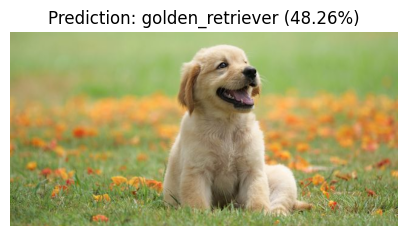

이미지: dog.jpg
golden_retriever: 48.26%
Labrador_retriever: 8.29%
kuvasz: 4.68%
--------------------------------------------------


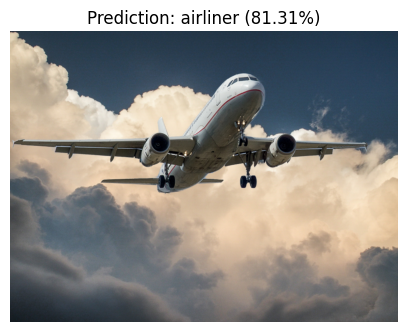

이미지: plane.jpg
airliner: 81.31%
wing: 3.85%
warplane: 1.57%
--------------------------------------------------


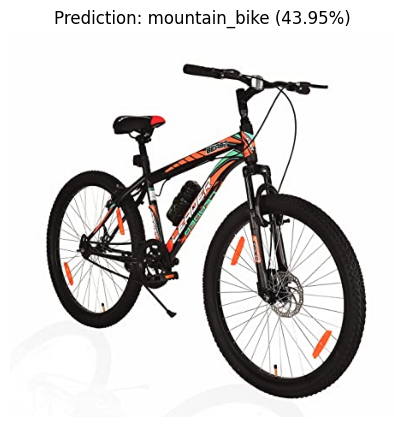

이미지: cycle.jpg
mountain_bike: 43.95%
tricycle: 13.17%
bicycle-built-for-two: 10.36%
--------------------------------------------------


In [30]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import decode_predictions

# 테스트 이미지 경로
test_dir = "/content/drive/MyDrive/33project/06.임베디드/03.efficientNet-2/tensorflow/efficientnet_tf/test_imgs"

# 사전 학습된 EfficientNet-B0 불러오기
model = EfficientNetB0(weights="imagenet")

# 이미지 목록
image_files = [
    f for f in os.listdir(test_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

print("테스트 이미지 개수:", len(image_files))

# 이미지 분류
for filename in image_files:
    image_path = os.path.join(test_dir, filename)

    img = Image.open(image_path).convert("RGB")
    resized_img = img.resize((224, 224))

    # EfficientNet 입력 형태로 변환
    img_array = np.array(resized_img, dtype=np.float32)
    img_array = np.expand_dims(img_array, axis=0)

    # 예측
    predictions = model.predict(img_array, verbose=0)
    results = decode_predictions(predictions, top=3)[0]

    # 결과 출력
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {results[0][1]} ({results[0][2]*100:.2f}%)")
    plt.show()

    print("이미지:", filename)

    for _, label, probability in results:
        print(f"{label}: {probability*100:.2f}%")

    print("-" * 50)